<a href="https://colab.research.google.com/github/mattsmiths/biol470/blob/main/final_project/FinalProject_Analysis_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
#@title Click to copy the class code repository
!git clone https://github.com/mattsmiths/biol470.git

Cloning into 'biol470'...
remote: Enumerating objects: 774, done.
remote: Counting objects: 100% (179/179), done.
remote: Compressing objects: 100% (89/89), done.
remote: Total 774 (delta 126), reused 122 (delta 90), pack-reused 595 (from 3)
Receiving objects: 100% (774/774), 928.79 MiB | 33.89 MiB/s, done.
Resolving deltas: 100% (284/284), done.
Updating files: 100% (302/302), done.


In [2]:
#@title Click to import libraries
import cv2 as cv
import os
import matplotlib.pyplot as plt
import numpy as np
import glob
import pandas as pd

In [107]:
data1 = pd.read_csv('/content/biol470/final_project/nicotine_bee_1/assay4_inf_final_bee_0415_exp_01_air_cam1_2026-04-15_18-02-38_key.csv')

In [108]:
data1.head()

,Unnamed: 0,filepath,centroid,x_min,y_min,x_max,y_max,detection_confidence
0,0,/Volumes/SmithL0/2026/BIOL470/Final/0415/bee_0...,"[2875.0, 2471.0]",2500,2119,3250,2823,0.768609
1,1,/Volumes/SmithL0/2026/BIOL470/Final/0415/bee_0...,"[2872.0, 2471.0]",2516,2122,3228,2820,0.756088
2,2,/Volumes/SmithL0/2026/BIOL470/Final/0415/bee_0...,"[2890.5, 2462.0]",2541,2092,3240,2832,0.776936
3,3,/Volumes/SmithL0/2026/BIOL470/Final/0415/bee_0...,"[2848.0, 2474.5]",2461,2105,3235,2844,0.790376
4,4,/Volumes/SmithL0/2026/BIOL470/Final/0415/bee_0...,"[2883.0, 2472.5]",2532,2106,3234,2839,0.786264


In [109]:
x_store = []
y_store = []

# Pulling out the centroid for each detection event
for ind,ele in enumerate(data1['x_min']):
  x_center = (ele+data1['x_max'][ind])/2
  y_center = (data1['y_min'][ind]+data1['y_max'][ind])/2
  x_store.append(x_center)
  y_store.append(y_center)





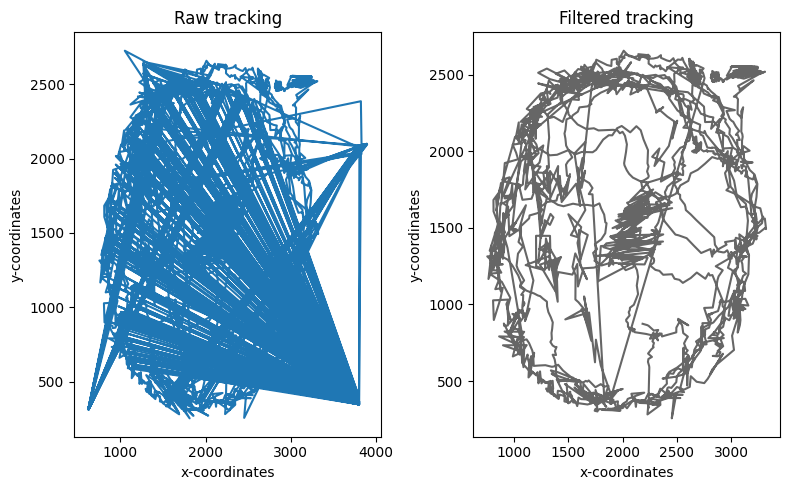

In [110]:
# Plotting the centroid in x-y space over time
# raw plot
plt.figure(figsize=(8,5))
plt.subplot(1,2,1)
plt.title('Raw tracking')
plt.plot(x_store,y_store)
plt.xlabel('x-coordinates')
plt.ylabel('y-coordinates')

speed = []
x_plot = []
y_plot = []
# updating to euclidean distance
for ind,x1 in enumerate(x_store[1:]):
  previous_pos = np.array([x_store[ind],y_store[ind]])
  current_pos = np.array([x_store[ind+1],y_store[ind+1]])

  # Euclidean distance calculation
  temp = np.linalg.norm((current_pos-previous_pos))

  speed.append(temp)

  # removing noise
  if temp < 250 and x_store[ind+1] < 3500:
    x_plot.append(x_store[ind+1])
    y_plot.append(y_store[ind+1])


plt.subplot(1,2,2)
plt.title('Filtered tracking')
plt.plot(x_plot,y_plot,color=(0.4,0.4,0.4))
plt.xlabel('x-coordinates')
plt.ylabel('y-coordinates')
plt.tight_layout()


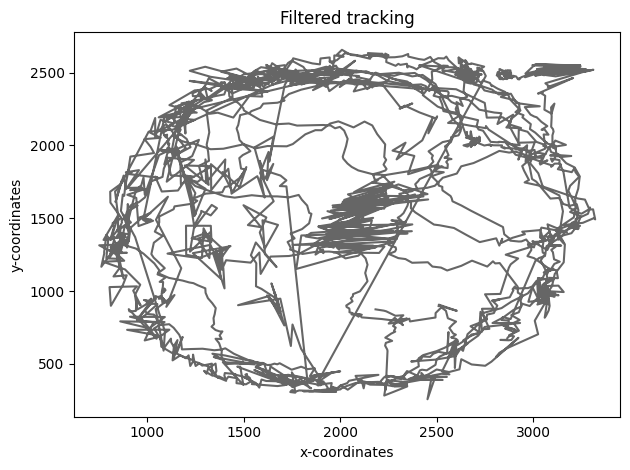

In [111]:

#plt.title('Filtered tracking')
plt.plot(x_plot,y_plot,color=(0.4,0.4,0.4))
plt.xlabel('x-coordinates')
plt.ylabel('y-coordinates')
plt.tight_layout()
plt.savefig('/content/circle.jpg',dpi=200)

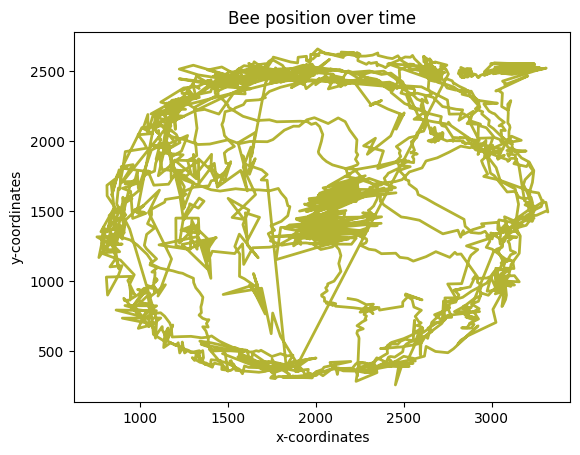

In [41]:
# Plotting the centroid in x-y space over time
plt.plot(x_plot,y_plot,color=(0.7,0.7,0.2),linewidth=2)
plt.xlabel('x-coordinates')
plt.ylabel('y-coordinates')
plt.title('Bee position over time')
plt.savefig('control_bee2_assay_1.pdf',dpi=200)

In [42]:
#xdiff = np.diff(x_store)
#ydiff = np.diff(y_store)
#out = abs(xdiff)+abs(ydiff)

speed = []
# updating to euclidean distance
for ind,x1 in enumerate(x_store[1:]):
  previous_pos = np.array([x_store[ind],y_store[ind]])
  current_pos = np.array([x_store[ind+1],y_store[ind+1]])

  # Euclidean distance calculation
  temp = np.linalg.norm((current_pos-previous_pos))

  speed.append(temp)

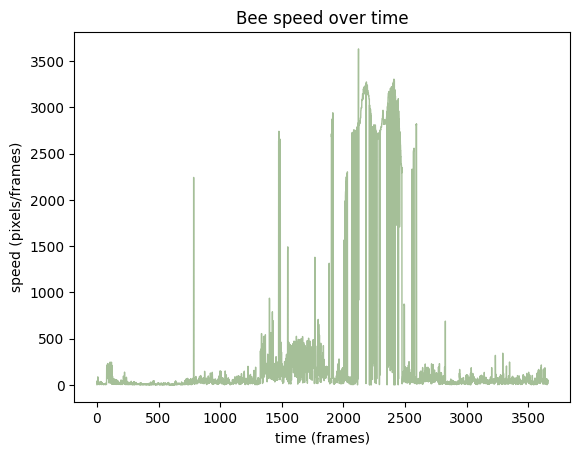

In [115]:
# Plotting the centroid in x-y space over time
plt.plot(speed,color=(0.3,0.5,0.2,0.5),linewidth=1)
plt.xlabel('time (frames)')
plt.ylabel('speed (pixels/frames)')
plt.title('Bee speed over time')
plt.savefig('control_bee2_assay_1_speed.pdf',dpi=200)

In [75]:
assayList = ['/content/biol470/final_project/control_bee_2/assay1_inf_bee_0408_2_opto_2026-04-08_16-35-41_arena_circle_1_key.csv',
             '/content/biol470/final_project/control_bee_3/assay1_inf_bee_0408_3_opto_2026-04-08_17-28-06_arena_circle_1_key.csv',
             '/content/biol470/final_project/control_bee_4/assay1_inf_bee_0408_4_opto_2026-04-08_18-08-46_arena_circle_1_key.csv']

allStore_control = []
for bees in assayList:

  data1 = pd.read_csv(bees)
  x_store = []
  y_store = []

  # Pulling out the centroid for each detection event
  for ind,ele in enumerate(data1['x_min']):
    x_center = (ele+data1['x_max'][ind])/2
    y_center = (data1['y_min'][ind]+data1['y_max'][ind])/2
    x_store.append(x_center)
    y_store.append(y_center)

  speed = []
  # updating to euclidean distance
  for ind,x1 in enumerate(x_store[1:]):
    previous_pos = np.array([x_store[ind],y_store[ind]])
    current_pos = np.array([x_store[ind+1],y_store[ind+1]])

    # Euclidean distance calculation
    temp = np.linalg.norm((current_pos-previous_pos))
    speed.append(temp)


  allStore_control.append(speed)

In [49]:
assayList = ['/content/biol470/final_project/nicotine_bee_1/assay1_inf_bee_0415_exp_01_opto_2026-04-15_17-11-24_arena_circle_1_key.csv',
             '/content/biol470/final_project/nicotine_bee_2/assay1_inf_bee_0415_exp_02_opto_2026-04-15_20-58-17_arena_circle_1_key.csv',
             '/content/biol470/final_project/nicotine_bee_3/assay1_inf_bee_0415_exp_03_opto_2026-04-15_22-25-20_arena_circle_1_key.csv']

allStore = []
for bees in assayList:

  data1 = pd.read_csv(bees)
  x_store = []
  y_store = []

  # Pulling out the centroid for each detection event
  for ind,ele in enumerate(data1['x_min']):
    x_center = (ele+data1['x_max'][ind])/2
    y_center = (data1['y_min'][ind]+data1['y_max'][ind])/2
    x_store.append(x_center)
    y_store.append(y_center)

    speed = []
    # updating to euclidean distance
    for ind,x1 in enumerate(x_store[1:]):
      previous_pos = np.array([x_store[ind],y_store[ind]])
      current_pos = np.array([x_store[ind+1],y_store[ind+1]])

      # Euclidean distance calculation
      temp = np.linalg.norm((current_pos-previous_pos))
      speed.append(temp)

  allStore.append(speed)

Text(0, 0.5, 'Avg Speed (pixels/frame)')

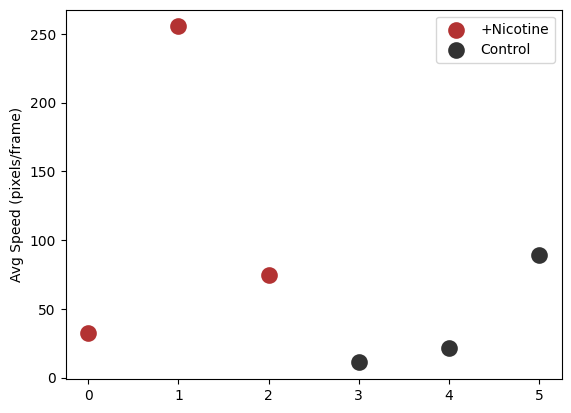

In [52]:
plt.figure()
for ind,ele in enumerate(allStore):
  if ind == 0:
    plt.scatter(ind,np.nanmean(ele),color=(0.7,0.2,0.2),linewidth=2,s=100,label='+Nicotine')
  else:
    plt.scatter(ind,np.nanmean(ele),color=(0.7,0.2,0.2),linewidth=2,s=100)

for ind,ele in enumerate(allStore_control):
  if ind == 0:
    plt.scatter(ind+3,np.nanmean(ele),color=(0.2,0.2,0.2),linewidth=2,s=100,label='Control')
  else:
    plt.scatter(ind+3,np.nanmean(ele),color=(0.2,0.2,0.2),linewidth=2,s=100)
plt.legend()

plt.ylabel('Avg Speed (pixels/frame)')



# Arena Circle

In [129]:
findBees = glob.glob('/content/biol470/final_project/*/assay1*')

allStore = {}
for bees in findBees:

  allStore[bees.split('/')[-2]] = []

  data1 = pd.read_csv(bees)
  x_store = []
  y_store = []

  # Pulling out the centroid for each detection event
  for ind,ele in enumerate(data1['x_min']):
    x_center = (ele+data1['x_max'][ind])/2
    y_center = (data1['y_min'][ind]+data1['y_max'][ind])/2
    x_store.append(x_center)
    y_store.append(y_center)

    speed = []
    # updating to euclidean distance
    for ind,x1 in enumerate(x_store[1:]):
      previous_pos = np.array([x_store[ind],y_store[ind]])
      current_pos = np.array([x_store[ind+1],y_store[ind+1]])

      # Euclidean distance calculation
      temp = np.linalg.norm((current_pos-previous_pos))
      speed.append(temp)

  allStore[bees.split('/')[-2]].append(speed)

# Optomotor

In [53]:
import math

In [ ]:
dx = x2 - x1
dy = y2 - y1
angle_rad = math.atan2(dy, dx)
angle_deg = math.degrees(angle_rad) # Convert radians to degrees

In [76]:
data1 = pd.read_csv(bees)
x_store = []
y_store = []
rad_store = []


x_store = []
y_store = []

# Pulling out the centroid for each detection event
for ind,ele in enumerate(data1['x_min']):
  x_center = (ele+data1['x_max'][ind])/2
  y_center = (data1['y_min'][ind]+data1['y_max'][ind])/2
  x_store.append(x_center)
  y_store.append(y_center)

speed = []
# updating to euclidean distance
for ind,x1 in enumerate(x_store[1:]):
  previous_pos = np.array([2000,1500])
  current_pos = np.array([x_store[ind+1],y_store[ind+1]])



  # Euclidean distance calculation
  temp = np.linalg.norm((current_pos-previous_pos))
  speed.append(temp)

  #if temp < 500 and x_store[ind+1] > 1000:

  dx = 2000 - x_store[ind]
  dy = 1500 - y_store[ind]
  angle_rad = math.atan2(dy, dx)
  rad_store.append(angle_rad)


In [103]:
assayList = ['/content/biol470/final_project/nicotine_bee_3/assay2_inf_bee_0415_exp_03_opto_2026-04-15_22-32-59_fwd_arena_opto_key.csv']

allStore = []

for bees in assayList:

  data1 = pd.read_csv(bees)
  x_store = []
  y_store = []
  rad_store = []
  # Pulling out the centroid for each detection event
  for ind,ele in enumerate(data1['x_min']):
    x_center = (ele+data1['x_max'][ind])/2
    y_center = (data1['y_min'][ind]+data1['y_max'][ind])/2
    x_store.append(x_center)
    y_store.append(y_center)

  speed = []
  fx = []
  fy = []
  # updating to euclidean distance
  for ind,x1 in enumerate(x_store[1:]):
    previous_pos = np.array([2000,1500])
    current_pos = np.array([x_store[ind+1],y_store[ind+1]])

    if x_store[ind+1] < 800:
      continue
    # Euclidean distance calculation
    temp = np.linalg.norm((current_pos-previous_pos))
    speed.append(temp)
    fx.append(x_store[ind+1])
    fy.append(y_store[ind+1])
    #if temp < 500 and x_store[ind+1] > 1000:
    dx = 2000 - x_store[ind]
    dy = 1500 - y_store[ind]
    angle_rad = math.atan2(dy, dx)

    rad_store.append(angle_rad)

  allStore.append(rad_store)

0.0009937939318202954


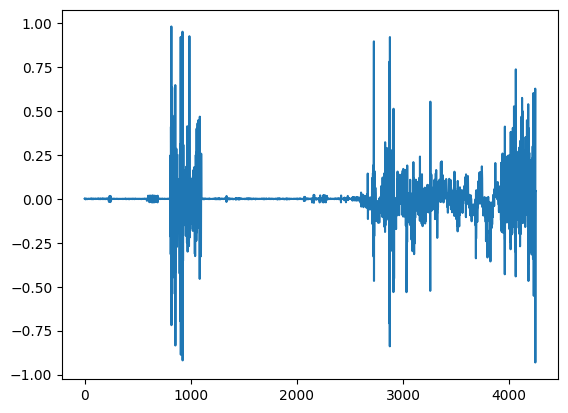

In [104]:
tz = np.diff(allStore[0])
pp = []
for ele in tz:
  if abs(ele) < 1:
    pp.append(ele)

plt.figure()
plt.plot(pp)
print(np.nanmean(pp))

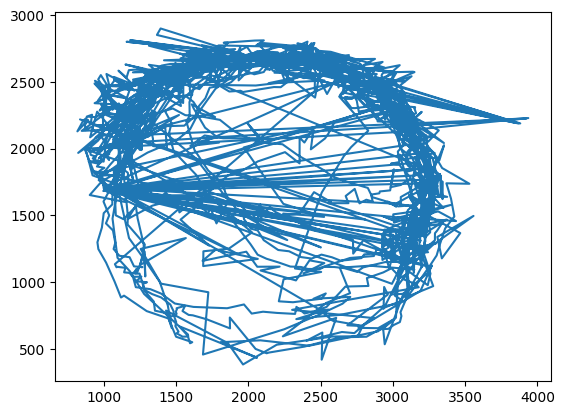

In [105]:
plt.plot(fx,fy)

# Shaded Preference

In [ ]:
findBees = glob.glob('/content/biol470/final_project/*/assay3*')

allStore = {}
for bees in findBees:

  allStore[bees.split('/')[-2]] = []

  data1 = pd.read_csv(bees)
  x_store = []
  y_store = []

  # Pulling out the centroid for each detection event
  for ind,ele in enumerate(data1['x_min']):
    x_center = (ele+data1['x_max'][ind])/2
    y_center = (data1['y_min'][ind]+data1['y_max'][ind])/2
    x_store.append(x_center)
    y_store.append(y_center)

    speed = []
    # updating to euclidean distance
    for ind,x1 in enumerate(x_store[1:]):
      previous_pos = np.array([x_store[ind],y_store[ind]])
      current_pos = np.array([x_store[ind+1],y_store[ind+1]])

      # Euclidean distance calculation
      temp = np.linalg.norm((current_pos-previous_pos))
      speed.append(temp)

  allStore[bees.split('/')[-2]].append(speed)

# Air Responses

In [ ]:
findBees = glob.glob('/content/biol470/final_project/*/assay4*')

allStore = {}
for bees in findBees:

  allStore[bees.split('/')[-2]] = []

  data1 = pd.read_csv(bees)
  x_store = []
  y_store = []

  # Pulling out the centroid for each detection event
  for ind,ele in enumerate(data1['x_min']):
    x_center = (ele+data1['x_max'][ind])/2
    y_center = (data1['y_min'][ind]+data1['y_max'][ind])/2
    x_store.append(x_center)
    y_store.append(y_center)

    speed = []
    # updating to euclidean distance
    for ind,x1 in enumerate(x_store[1:]):
      previous_pos = np.array([3200,1500])
      current_pos = np.array([x_store[ind+1],y_store[ind+1]])

      # Euclidean distance calculation
      temp = np.linalg.norm((current_pos-previous_pos))
      speed.append(temp)

  allStore[bees.split('/')[-2]].append(speed)


# Citronella Responses

In [ ]:
findBees = glob.glob('/content/biol470/final_project/*/assay5*')

allStore = {}
for bees in findBees:

  allStore[bees.split('/')[-2]] = []

  data1 = pd.read_csv(bees)
  x_store = []
  y_store = []

  # Pulling out the centroid for each detection event
  for ind,ele in enumerate(data1['x_min']):
    x_center = (ele+data1['x_max'][ind])/2
    y_center = (data1['y_min'][ind]+data1['y_max'][ind])/2
    x_store.append(x_center)
    y_store.append(y_center)

    speed = []
    # updating to euclidean distance
    for ind,x1 in enumerate(x_store[1:]):
      previous_pos = np.array([3200,1500])
      current_pos = np.array([x_store[ind+1],y_store[ind+1]])

      # Euclidean distance calculation
      temp = np.linalg.norm((current_pos-previous_pos))
      speed.append(temp)

  allStore[bees.split('/')[-2]].append(speed)


# Linalool Responses

In [ ]:
findBees = glob.glob('/content/biol470/final_project/*/assay6*')

allStore = {}
for bees in findBees:

  allStore[bees.split('/')[-2]] = []

  data1 = pd.read_csv(bees)
  x_store = []
  y_store = []

  # Pulling out the centroid for each detection event
  for ind,ele in enumerate(data1['x_min']):
    x_center = (ele+data1['x_max'][ind])/2
    y_center = (data1['y_min'][ind]+data1['y_max'][ind])/2
    x_store.append(x_center)
    y_store.append(y_center)

    speed = []
    # updating to euclidean distance
    for ind,x1 in enumerate(x_store[1:]):
      previous_pos = np.array([3200,1500])
      current_pos = np.array([x_store[ind+1],y_store[ind+1]])

      # Euclidean distance calculation
      temp = np.linalg.norm((current_pos-previous_pos))
      speed.append(temp)

  allStore[bees.split('/')[-2]].append(speed)
